---
#**Project 1 - PCA (principal component analysis) for GRACE and GRACE-FO mascon data**
## Perform signal separation of GRACE data over the Indus Basin with PCA and EOF (empirical orthogonal function) analysis
####authors:
  - Alice Ferrini (aferrini@student.ethz.ch)
  - Jérémie Pierre (jpierre@student.ethz.ch)
---

____

##**Table of Contents**
1. Initialize, import libraries and authenticate to gee
2. Data Processing and Study Area Definition
   
   2.1. Indus Basin (in total)

   2.2. Lower Indus Basin

3. Get and prepare GRACE data
4. Perform EOF analysis of India and Pakistan

   4.1. Data preparation, land-only mask and gap handling

   4.2. PCA

   4.3. Preparation of plotting functions

   4.4. Plotting results of PCA(=EOF analysis)
5. Reconstruct the data with main mode(s) for the lower Indus Basin, compute the trend(s) and plot it

   5.1. Compute the overlap of each grid cell with the lower Indus Basin (as defined by lower_poly)

   5.2. Analyze the trend of the first mode

   5.2.1. Reconstruct the data from the first mode

   5.2.2. Plot one of the data points to verify that the selected data is indeed only the lower Indus Basin

   5.2.3. Compute the trend by integrating over the spatial dimension

   5.2.4. Separating 12-month periodic signal from the trend

   5.3. Reconstruct data for the second mode, compute its trend and plot it

6. Perform EOF analysis of Indus Basin only

7. External dataset: Data Extraction and Time Series Construction

   7.1. Approximation of climate-driven ∆TWS

   7.2. Approximation of anthropogenic-driven ∆TWS

8. External Dataset: Results and Data Visualization

   8.1. Temporal Evolution of Precipitation, Evapotranspiration and Runoff

   8.2. Temporal Evolution of Cropland Extent and Irrigation Water Demand by Crop

   8.3. Time Series Analysis of climate and anthropogenic ∆TWS Components
   
   8.3.1. Annual ∆TWS: Climate-driven vs Anthropogenic contribution

   8.3.2. Cumulative ∆TWS Anomaly: Climate vs Anthropogenic signal

# 1. Initialize, import libraries and authenticate to gee

In [5]:
!pip install -q cartopy rioxarray netCDF4
!pip install -q cartopy

In [11]:
import ee
import geemap
import geemap.colormaps as cm

#processes the data
import numpy as np
import pandas as pd

# helps visualize the data
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
from shapely.geometry import Point, box, Polygon
import geopandas as gpd
import cartopy.feature as cfeature

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
matplotlib.rcParams['date.epoch'] = '2002-01-01T00:00:00Z'
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

import xarray as xr
import requests, io
import geopandas as gpd

import os

# reads the .nc and .nc4 files
import netCDF4 as nc


from datetime import datetime

from sklearn.decomposition import PCA

import warnings
# remove the warning due to timezones representation missing for np.datetime64 to improve the plotting quality
warnings.filterwarnings("ignore", message="no explicit representation of timezones available for np.datetime64")

In [12]:
# Authenticate with Google Earth Engine using the user's Google account.
# The project ID is specified to ensure that computations run under the correct Google Cloud project.
# Access to this project should have been granted to collaborators/reviewers via IAM permissions.

ee.Authenticate()
ee.Initialize(project='space-data-490607')

# 2. Data Processing and Study Area Definition

### 2.1. Indus Basin (in total)

In [13]:
# Download HydroBasins shapefile from GitHub
BASE_URL = "https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/"
hydro_files = {
    "prj": "hybas_as_lev06_v1c.prj",
    "sbn": "hybas_as_lev06_v1c.sbn",
    "sbx": "hybas_as_lev06_v1c.sbx",
    "shx": "hybas_as_lev06_v1c.shx",
    "shp": "hybas_as_lev06_v1c.shp",
    "dbf": "hybas_as_lev06_v1c.dbf",
}

os.makedirs("HydroBasin", exist_ok=True)

for ext, filename in hydro_files.items():
    url = BASE_URL + filename
    print(url)
    response = requests.get(url)
    response.raise_for_status()
    with open(os.path.join("HydroBasin", filename), "wb") as f:
        f.write(response.content)

print("HydroBasin shapefile downloaded.")


# Load shapefile into GeoDataFrame
gdf = gpd.read_file("HydroBasin/hybas_as_lev06_v1c.shp")
print("HydroBasin dataset loaded.")

# Identify the Indus Basin using a control point
# A known point inside the basin retrieves the MAIN_BAS ID
indus_point = Point(73.13, 31.41)
target_row = gdf[gdf.contains(indus_point)]

if not target_row.empty:
    indus_main_id = target_row["MAIN_BAS"].iloc[0]
    print(f"Indus MAIN_BAS ID detected: {indus_main_id}")

    # Merge all sub-basins into a single outline
    indus_gdf = gdf[gdf["MAIN_BAS"] == indus_main_id]
    indus_outline = indus_gdf.dissolve()
    print("Indus Basin contour extracted successfully.")

else:
    raise ValueError("Error: the point is not contained in the HydroBasin file.")

# Simplify geometry for Earth Engine compatibility
# (0.01° ~ 1 km precision, prevents memory errors in EE)
raw_geom = indus_outline.geometry.iloc[0]
geom_simplified = raw_geom.simplify(0.01, preserve_topology=True)

# Extract bounding box and define year range
bounds = indus_outline.total_bounds
lon_min, lat_min, lon_max, lat_max = bounds
years = list(range(2003, 2024))

print(f"Geometry type: {geom_simplified.geom_type}")
print(f"Bounding box — lat: [{lat_min:.2f}, {lat_max:.2f}] | lon: [{lon_min:.2f}, {lon_max:.2f}]")

https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.prj
https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.sbn
https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.sbx
https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.shx
https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.shp
https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/HydroBasin/hybas_as_lev06_v1c.dbf
HydroBasin shapefile downloaded.
HydroBasin dataset loaded.
Indus MAIN_BAS ID detected: 4060033640
Indus Basin contour extracted successfully.
Geometry type: MultiPolygon
Bounding box — lat: [24.03, 37.10] | lon: [66.16, 82.45]


Display the basin and some variables such as cropland or snow cover.

In [14]:
# Load HydroBasin shapefile and extract Indus Basin geometry
gdf = gpd.read_file("HydroBasin/hybas_as_lev06_v1c.shp")
basin = gdf.cx[60.0:75.0, 23.0:33.0].dissolve()
basin_geojson = basin.geometry.iloc[0].__geo_interface__
basin_ee      = ee.Geometry(basin_geojson)

indus_fc = geemap.geopandas_to_ee(indus_outline)

# MODIS Land Cover: extract cropland classes clipped to Indus outline
modis_lc = (ee.ImageCollection('MODIS/061/MCD12Q1')
              .filterDate('2022-01-01', '2023-01-01')
              .first()
              .select('LC_Type1'))

cropland_mask = modis_lc.eq(12).Or(modis_lc.eq(14))
cropland_img  = cropland_mask.updateMask(cropland_mask).clip(indus_fc)

# MODIS Snow Cover: annual mean within the full Indus Basin
# (Flag values >100 are replaced with 0; only pixels with snow >10% of the year are kept)
snow_clean = (ee.ImageCollection('MODIS/061/MOD10A1')
                .filterDate('2022-01-01', '2023-01-01')
                .filterBounds(basin_ee)
                .select('NDSI_Snow_Cover')
                .map(lambda img: img.where(img.gt(100), 0))
                .mean()
                .updateMask(
                    ee.ImageCollection('MODIS/061/MOD10A1')
                    .filterDate('2022-01-01', '2023-01-01')
                    .select('NDSI_Snow_Cover')
                    .map(lambda img: img.where(img.gt(100), 0))
                    .mean()
                    .gt(10)
                )
                .clip(basin_ee))

# Build basin boundary layers from indus_outline
indus_fc = geemap.geopandas_to_ee(indus_outline)

basin_fill = ee.Image().byte().paint(
    featureCollection=indus_fc, color=1)

basin_outline_ee = ee.Image().byte().paint(
    featureCollection=indus_fc, color=1, width=2)

# Build interactive map
Map = geemap.Map()
Map.centerObject(basin_ee, zoom=6)
Map.add_basemap('HYBRID')

Map.addLayer(basin_fill,
    {'palette': ['#dc143c'], 'min': 0, 'max': 1},
    'Indus Basin fill', opacity=0.15)

Map.addLayer(cropland_img,
    {'palette': ['#c8b400'], 'min': 0, 'max': 1},
    'Cropland (MODIS cl.12+14)', opacity=0.85)

Map.addLayer(snow_clean,
    {'min': 0, 'max': 60, 'palette': ['#e8f4f8', '#a8d8ea', '#0077b6', '#023e8a']},
    'Snow/Ice Cover (MOD10A1, 2022)', opacity=0.8)

Map.addLayer(basin_outline_ee,
    {'palette': ['#dc143c'], 'min': 0, 'max': 1},
    'Indus Basin boundary', opacity=1.0)

# Add markers: control point and capital cities
Map.add_marker(location=[31.41, 73.13], tooltip='Control point')

capitals = {'New Delhi': (77.209, 28.613), 'Islamabad': (73.047, 33.684)}
for name, (lon, lat) in capitals.items():
    Map.add_marker(location=[lat, lon], tooltip=name)

# Add legend and layer control
legend_dict = {
    'Cropland (MODIS cl.12+14)':  '#c8b400',
    'Snow/Ice (low frequency)':   '#a8d8ea',
    'Snow/Ice (high frequency)':  '#023e8a',
    'Indus Basin boundary':       '#dc143c',
}
Map.add_legend(title='Legenda', legend_dict=legend_dict, position='bottomleft')
Map.addLayerControl()

Map

Map(center=[28.208105337018637, 71.881931478369], controls=(WidgetControl(options=['position', 'transparent_bg…

### 2.2. Lower Indus Basin

In [16]:
# Load Lower Indus Basin boundary from manually digitized coordinates
# (The polygon was drawn in Google Earth Pro and exported as CSV (lat/lon columns))

csv_url      = "https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/lower_indus_basin_coords.csv"
df           = pd.read_csv(csv_url)
coords_list  = list(zip(df['Longitude_E'], df['Latitude_N']))
lower_poly   = Polygon(coords_list)
indus_geom   = ee.Geometry(lower_poly.__geo_interface__)

# 3. Get and prepare GRACE data

In [17]:
# LOAD DATA
file_url = 'https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/GRCTellus.JPL.200204_202512.GLO.RL06.3M.MSCNv04CRI.nc'

response = requests.get(file_url)
mascons_xr = xr.open_dataset(io.BytesIO(response.content))

In [18]:
# Convert to a netCDF4 dataset to be consistent with the EOF analysis code
# Save the xarray Dataset to an in-memory buffer
memory_buffer = io.BytesIO()
mascons_xr.to_netcdf(memory_buffer)

# Reset the buffer's position to the beginning
memory_buffer.seek(0)

# Open the in-memory buffer as a netCDF4.Dataset
mascons = nc.Dataset('in_memory.nc', mode='r', memory=memory_buffer.read())

In [19]:
n_time = len(mascons.dimensions['time'])
n_lon = len(mascons.dimensions['lon'])
n_lat = len(mascons.dimensions['lat'])

lons = np.array(mascons.variables["lon"][:])
lats = np.array(mascons.variables["lat"][:])
data = np.array(mascons.variables["lwe_thickness"][:])

times = mascons.variables["time"][:]
dates = np.array(mdates.num2date(times, tz='UTC'))

In [20]:
dates_pd = pd.to_datetime(dates)
date_periods = dates_pd.to_period('M')

# Generate a complete monthly sequence
full_periods = pd.period_range(start=date_periods.min(),
                               end=date_periods.max(),
                               freq='M')

# Determine the missing months
missing_periods = full_periods.difference(date_periods)
print(full_periods.shape, date_periods.shape, missing_periods.shape)

print("Missing months:")
print(missing_periods)

(285,) (252,) (35,)
Missing months:
PeriodIndex(['2002-06', '2002-07', '2003-06', '2011-01', '2011-06', '2011-12',
             '2012-05', '2012-10', '2013-03', '2013-08', '2013-09', '2014-02',
             '2014-07', '2014-12', '2015-05', '2015-06', '2015-10', '2015-11',
             '2016-04', '2016-09', '2016-10', '2017-02', '2017-07', '2017-08',
             '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02',
             '2018-03', '2018-04', '2018-05', '2018-08', '2018-09'],
            dtype='period[M]')


# 4. Perform EOF analysis of India and Pakistan

### 4.1. Data preparation, land-only mask and gap handling

In [21]:
# Prepare data

# Define region bounds for India
lat_min, lat_max = 8, 40
lon_min, lon_max = 60, 90
extent = (lon_min-4, lon_max+4, lat_min-4, lat_max+4)

# Create ROI mask
lat_mask = (lats >= lat_min) & (lats <= lat_max)
lon_mask = (lons >= lon_min) & (lons <= lon_max)

# Apply land-only mask
land_data = np.where(mascons['land_mask'], data, 0)

# Apply mask
data_region = land_data[:, lat_mask][:, :, lon_mask]
print(data_region.shape)
n_t, n_lat_r, n_lon_r = data_region.shape

# Flatten spatial dimensions
data_region_flat = data_region.reshape(n_t, n_lat_r * n_lon_r)
data_mean_r = np.mean(data_region_flat, axis=0)
data_centered_r = data_region_flat - data_mean_r

print(data_centered_r.shape, data_mean_r.shape)

(252, 64, 60)
(252, 3840) (3840,)


In [22]:
# Interpolate ≤2-months gaps

# Convert to DataFrame (time × space)
data_df = pd.DataFrame(data_centered_r, index=date_periods)

# Remove duplicate months if present
data_df = data_df.groupby(level=0).mean()


# Insert missing months
data_df_full = data_df.reindex(full_periods)

# Interpolate only short gaps (≤2 months)
data_interp = data_df_full.interpolate(method='linear', limit=2)

data_interp_np = data_interp.values

valid_rows = ~np.isnan(data_interp_np).any(axis=1)

data_interp_clean = data_interp_np[valid_rows]
dates_clean = data_interp.index[valid_rows]

### 4.2. PCA

In [23]:
pca_r = PCA(n_components=0.99)
pca_r.fit(data_interp_clean)

transformed_r = pca_r.transform(data_interp_clean)
explained_variance_r = pca_r.explained_variance_ratio_

eof_patterns_r = [pca_r.components_[i].reshape(n_lat_r, n_lon_r) for i in range(pca_r.n_components_)]
minmax_r = [np.max(np.abs(eof_patterns_r[i])) for i in range(len(eof_patterns_r))]

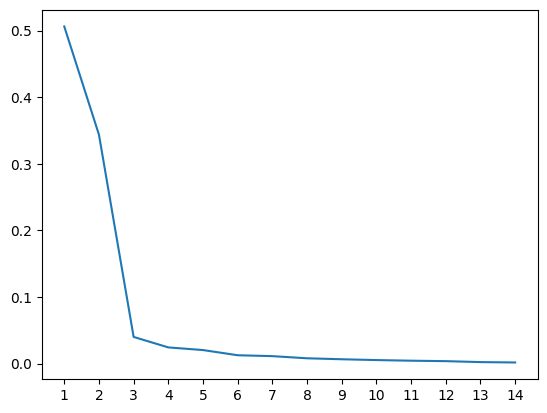

In [24]:
# explained variance

plt.plot(np.arange(1, len(explained_variance_r)+1, 1), explained_variance_r)
plt.xticks(np.arange(1, len(explained_variance_r)+1, step=1))
# plt.yscale('log')
plt.show()

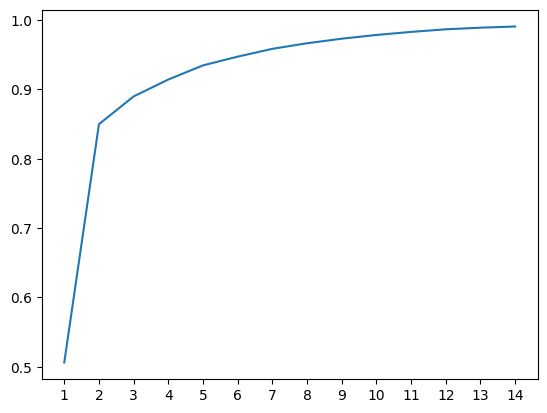

[0.50615187 0.84985739 0.88996402 0.91434583 0.93473909 0.94734702
 0.95860944 0.96665405 0.97323994 0.97861045 0.98303091 0.98678324
 0.98910035 0.99085303]


In [25]:
# cumulative explained variance

prefix_sum = np.copy(explained_variance_r)
for i in range(1, len(prefix_sum)):
    prefix_sum[i] += prefix_sum[i-1]
plt.plot(np.arange(1, len(explained_variance_r)+1, step=1), prefix_sum)
plt.xticks(np.arange(1, len(explained_variance_r)+1, step=1))
# plt.yscale('log')
plt.show()
print(prefix_sum)

We can see that the two first modes explain most of the variance and that 4 modes already explain more than 90% of the variance.

### 4.3. Preparation of plotting functions

In [26]:
def plot_mesh_1(lons, lats, data, title="", cbar_label="", cmap='RdBu_r', vmin=-200, vmax=200, extent=None, adapt_cbar=True, ax=None, fig=None):
    if ax is None or fig is None:
        fig = plt.figure(figsize=(12,6))
        ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines(resolution='110m')

    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

    capitals = {
        'New Delhi': (77.209, 28.613),
        'Islamabad': (73.047, 33.684)
    }
    for name, (lon, lat) in capitals.items():
        ax.plot(lon, lat, 'ko', markersize=4, transform=ccrs.PlateCarree())
        ax.text(lon + 0.5, lat + 0.5, name, fontsize=9, transform=ccrs.PlateCarree())

    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        lons_ma = (extent[0] <= lons) & (lons <= extent[1])
        lats_ma = (extent[2] <= lats) & (lats <= extent[3])
        # print(lons[lons_ma])
        # print(lats[lats_ma])

        data_ma = data[lats_ma, :][:, lons_ma]
        # print(data_ma.shape, data_ma)
        # print(np.all(data[np.ix_(lats_ma, lons_ma)] == data_ma))

        max_val = np.nanmax(np.abs(data[np.ix_(lats_ma, lons_ma)]))
        # print(max_val, np.max(data_ma), np.min(data_ma), np.where(data_ma == max_val))
        max_zone = np.where(data_ma == max_val)
        # print(lons[lons_ma][max_zone[0]], lats[lats_ma][max_zone[1]])

        if adapt_cbar and max_val < vmax and -max_val > vmin:
            vmin = -max_val
            vmax = max_val

    plotted = plt.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(), cmap=cmap,vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(plotted, extend='both')
    cbar.minorticks_on()
    ax.set_title(title)
    cbar.ax.set_ylabel(cbar_label)


    ax.add_geometries([geom_simplified], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue')


    # ax.gridlines()

In [27]:
def plot_n_r(n):
    # Plot first n EOFs and their time series
    fig, axes = plt.subplots(n, 2, figsize=(15, 10))  # n rows, 2 columns
    minmax_n = np.max(minmax_r[:n])
    minmax_pc = np.max(np.abs(transformed_r[:, :]))
    for i in range(n):  # Plot first n EOFs and their time series
        # EOF spatial pattern

        # ax = axes[i, 0](projection=ccrs.Robinson())
        # ax.coastlines(resolution='110m')
        axes[i, 0].remove()
        ax = fig.add_subplot(n, 2, 2*i+1, projection=ccrs.PlateCarree())
        ax.coastlines(resolution='110m')


        plot_mesh_1(lons[lon_mask], lats[lat_mask], eof_patterns_r[i], cmap='RdBu_r', vmin=-minmax_n/1.5, vmax=minmax_n/1.5, ax=ax, fig=fig)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f'EOF {i+1} ({explained_variance_r[i]*100:.2f}% variance)')
        # fig.colorbar(im, ax=axes[i, 0])

        # Principal component time series
        pc_series = pd.Series(transformed_r[:, i], index=dates_clean)
        pc_series = pc_series.groupby(level=0).mean()
        pc_series_full = pc_series.reindex(full_periods)
        plot_dates = pc_series_full.index.to_timestamp()

        axes[i, 1].plot(plot_dates, pc_series_full.values, label=f'PC {i+1}', color='b')
        axes[i, 1].set_yticks([-minmax_pc, -minmax_pc/2, 0, minmax_pc/2, minmax_pc])
        axes[i, 1].set_title(f'PC {i+1} Time Series')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.savefig('EOF.png')
    plt.show()

### 4.4. Plotting results of PCA(=EOF analysis)

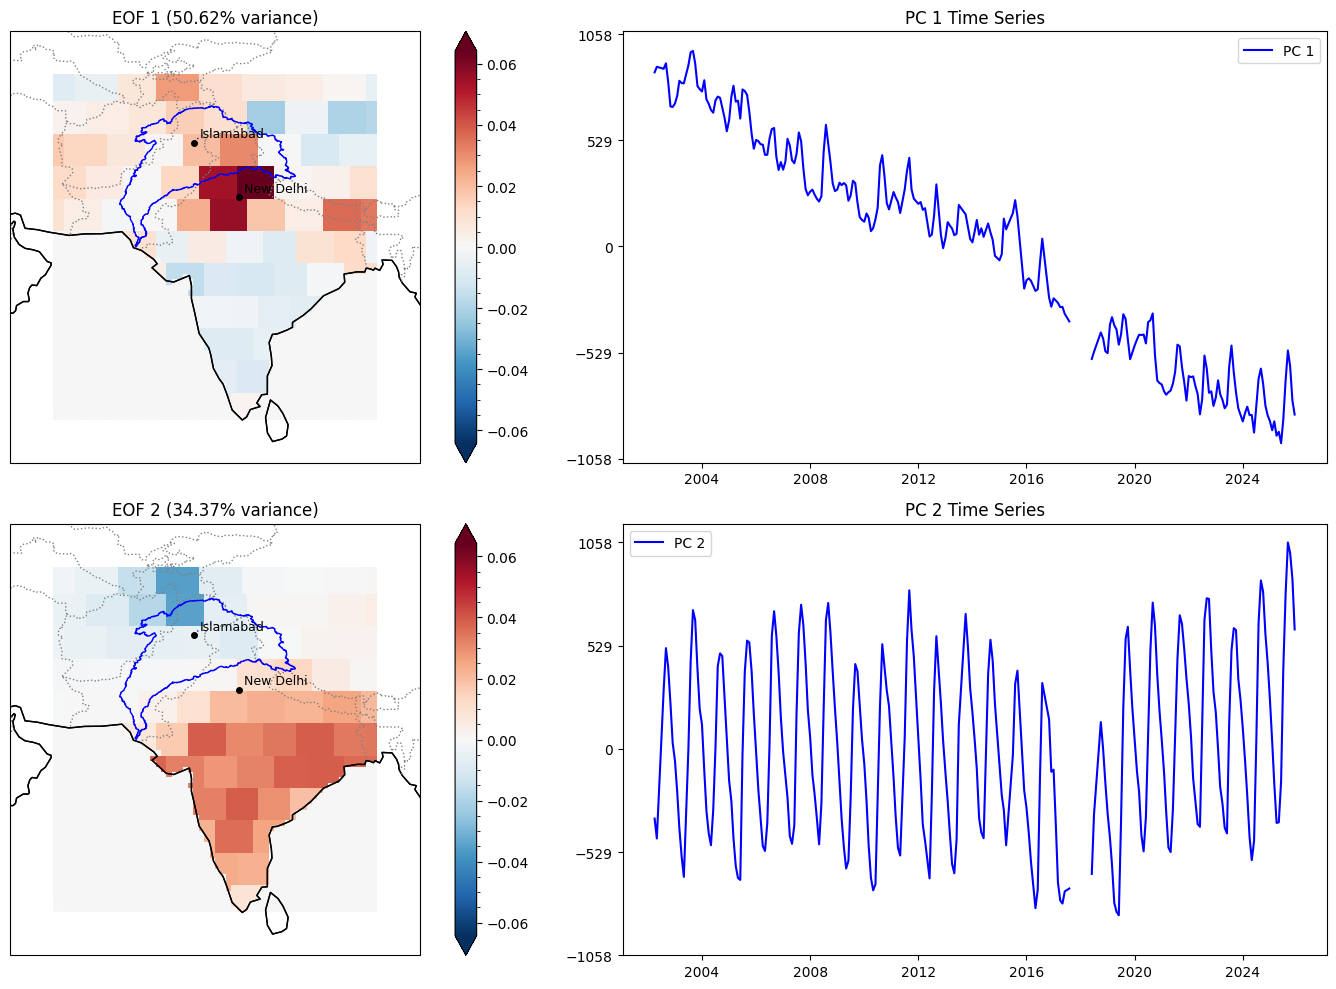

In [28]:
plot_n_r(2)

# 5. Reconstruct the data with main mode(s) for the lower Indus Basin, compute the trend(s) and plot it

### 5.1. Compute the overlap of each grid cell with the lower Indus Basin (as defined by `lower_poly`)

In [29]:
dlat = np.abs(lats[1] - lats[0])
dlon = np.abs(lons[1] - lons[0])
print(dlat, dlon)

0.5 0.5


In [30]:
lon2d, lat2d = np.meshgrid(lons[lon_mask], lats[lat_mask])

In [31]:
R = 6371e3  # Earth radius in meters

lat_rad_1 = np.deg2rad(lat2d - dlat/2)
lat_rad_2 = np.deg2rad(lat2d + dlat/2)

cell_area = R**2 * np.deg2rad(dlon) * (np.sin(lat_rad_2) - np.sin(lat_rad_1))

In [32]:
weights = np.zeros_like(lat2d, dtype=float)

for i in range(lat2d.shape[0]):
    for j in range(lat2d.shape[1]):
        cell = box(
            lon2d[i, j] - dlon/2,
            lat2d[i, j] - dlat/2,
            lon2d[i, j] + dlon/2,
            lat2d[i, j] + dlat/2
        )

        inter = cell.intersection(lower_poly)

        if not inter.is_empty:
            frac = inter.area / cell.area
            weights[i, j] = frac * cell_area[i, j]

In [33]:
weights = weights / np.sum(weights)  # normalize by sum to get an average over the area when multiplying data with those weights
print(np.max(weights), np.max(cell_area))

0.006881382031359962 3059079851.3043075


### 5.2. Analyze the trend of the first mode

5.2.1. Reconstruct the data from the first mode

In [34]:
k = 0
reconstructed_data = np.dot(transformed_r[:, k:k+1], pca_r.components_[k:k+1, :]) + data_mean_r
reconstructed_data_reshaped = reconstructed_data.reshape(-1, n_lat_r, n_lon_r)

5.2.2. Plot one of the data points to verify that the selected data is indeed only the lower Indus Basin

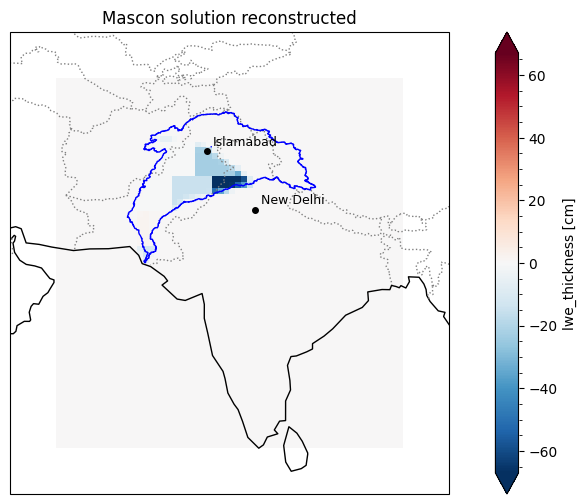

In [35]:
plot_mesh_1(lons[lon_mask], lats[lat_mask], (reconstructed_data_reshaped * (weights/np.max(weights)))[250], extent=extent, title="Mascon solution reconstructed", cbar_label="lwe_thickness [cm]", adapt_cbar=True)

5.2.3. Compute the trend by integrating over the spatial dimension

In [36]:
TWS_basin = (reconstructed_data_reshaped * weights).sum(axis=(1,2))

Text(0.5, 1.0, 'Trend of first mode')

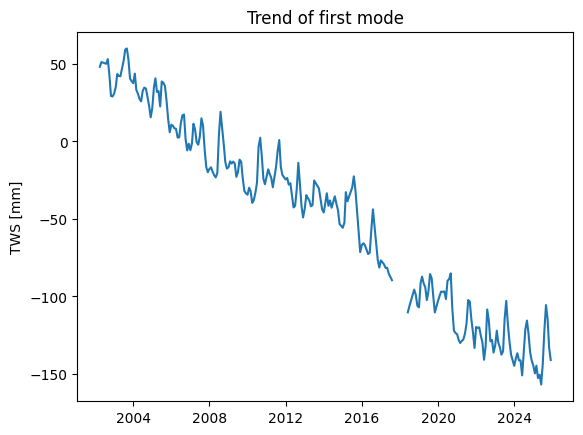

In [37]:
pc_series = pd.Series(TWS_basin*10, index=dates_clean)
pc_series = pc_series.groupby(level=0).mean()
pc_series_full = pc_series.reindex(full_periods)
plot_dates = pc_series_full.index.to_timestamp()

plt.plot(plot_dates, pc_series_full.values)

plt.ylabel('TWS [mm]')
plt.title('Trend of first mode')

5.2.4. Separating 12-month periodic signal from the trend

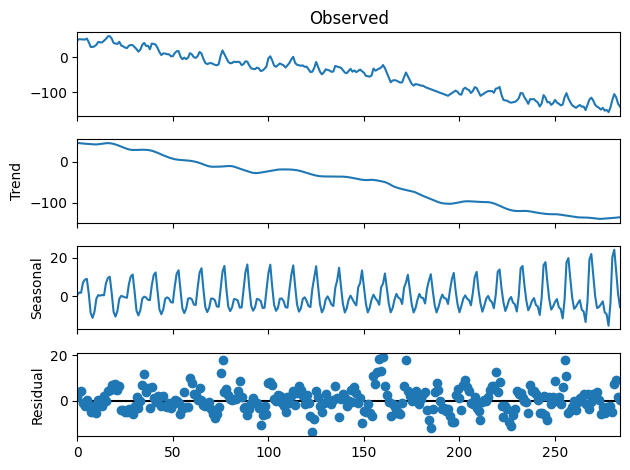

In [38]:
# extracting the trend from the TWS derived from the first PC-EOF on interpolated data
pc_series = pd.Series(TWS_basin*10, index=dates_clean)
pc_series = pc_series.groupby(level=0).mean()
pc_series_full = pc_series.reindex(full_periods)
plot_dates = pc_series_full.index.to_timestamp()

# removing the gaps because it is needed by the trend analyser methods
interpolated = pc_series_full.interpolate(method='linear', limit=12)

# the first trend analysis method (https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html) allows for variable seasonal patterns while the second method (https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) assumes fixed seasonal patterns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
dec = seasonal_decompose(interpolated.values, model='additive', period=12)
stl = STL(interpolated.values, seasonal=13, period=12, trend=None, robust=True).fit()
f = stl.plot(observed=True, trend=True, seasonal=True, resid=True)
# plt.xlabel('time')
# plt.ylabel(r'$\Delta$ TWS [mm]')
plt.savefig('trend2.png')
# _ = dec.plot()

-7.662111106130981
-8.00515611684895


<Figure size 800x100 with 0 Axes>

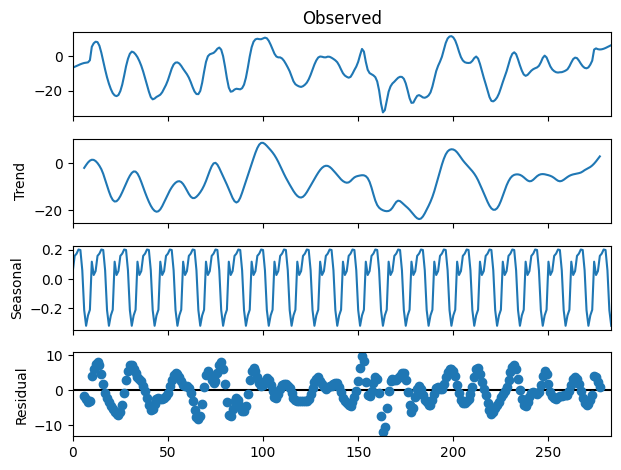

In [39]:
# trend "acceleration", and trend analysis of it, using the method with fixed seasonal patterns
fig = plt.figure(figsize=(8, 1))
delta_trend = (stl.trend[1:]-stl.trend[:-1])*12
print(np.mean(delta_trend))
# plt.plot(delta_trend)
# stl2 = STL(delta_trend, seasonal=13, period=12, trend=None, robust=True).fit()
# _ = stl2.plot()
dec2 = seasonal_decompose(delta_trend, model='additive', period=12)
print(np.nanmean(dec2.trend))
_ = dec2.plot()

### 5.3. Reconstruct data for the second mode, compute its trend and plot it

In [40]:
k = 1
reconstructed_data = np.dot(transformed_r[:, k:k+1], pca_r.components_[k:k+1, :]) + data_mean_r
reconstructed_data_reshaped = reconstructed_data.reshape(-1, n_lat_r, n_lon_r)

Text(0.5, 1.0, 'Trend of second mode')

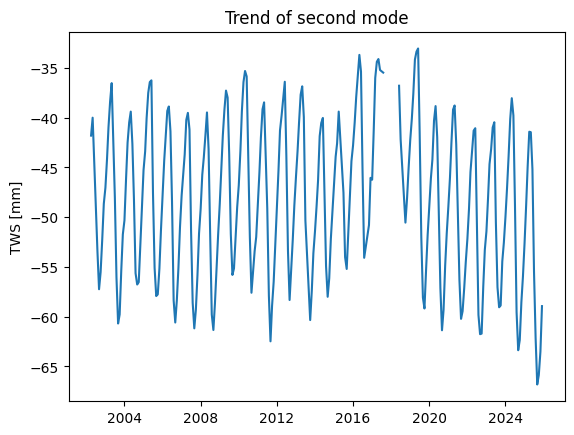

In [41]:
TWS_basin = (reconstructed_data_reshaped * weights).sum(axis=(1,2))

pc_series = pd.Series(TWS_basin*10, index=dates_clean)
pc_series = pc_series.groupby(level=0).mean()
pc_series_full = pc_series.reindex(full_periods)
plot_dates = pc_series_full.index.to_timestamp()

plt.plot(plot_dates, pc_series_full.values)

plt.ylabel('TWS [mm]')
plt.title('Trend of second mode')

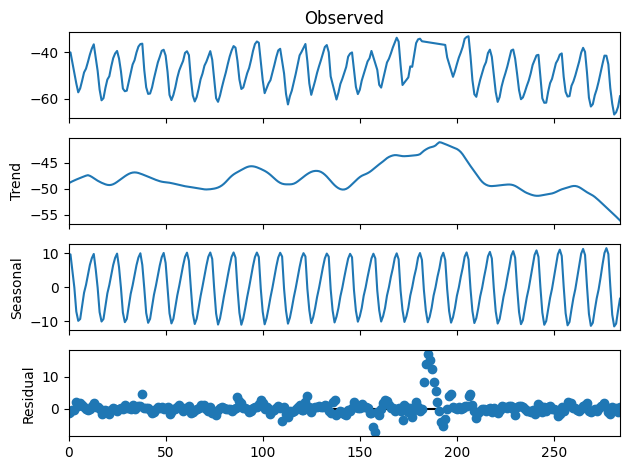

In [42]:
# extracting the trend from the TWS derived from the second PC-EOF on interpolated data
pc_series = pd.Series(TWS_basin*10, index=dates_clean)
pc_series = pc_series.groupby(level=0).mean()
pc_series_full = pc_series.reindex(full_periods)
plot_dates = pc_series_full.index.to_timestamp()

# removing the gaps because it is needed by the trend analyser methods
interpolated = pc_series_full.interpolate(method='linear', limit=12)

# the first trend analysis method (https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html) allows for variable seasonal patterns while the second method (https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) assumes fixed seasonal patterns
dec = seasonal_decompose(interpolated.values, model='additive', period=12)
stl = STL(interpolated.values, seasonal=13, period=12, trend=None, robust=True).fit()
f = stl.plot(observed=True, trend=True, seasonal=True, resid=True)
# plt.xlabel('time')
# plt.ylabel(r'$\Delta$ TWS [mm]')
plt.savefig('trend2.png')
# _ = dec.plot()

# 6. Perform EOF analysis of Indus Basin only

In [43]:
# Data for Lower Indus Basin only
data_interp_clean_reshaped = data_interp_clean.reshape(-1, n_lat_r, n_lon_r)
data_interp_clean_reshaped_li = data_interp_clean_reshaped * (weights/np.max(weights))
data_interp_clean_li = data_interp_clean_reshaped_li.reshape(-1, n_lat_r*n_lon_r)

In [44]:
pca_r = PCA(n_components=0.99)
pca_r.fit(data_interp_clean_li)

transformed_r = pca_r.transform(data_interp_clean_li)
explained_variance_r = pca_r.explained_variance_ratio_

eof_patterns_r = [pca_r.components_[i].reshape(n_lat_r, n_lon_r) for i in range(pca_r.n_components_)]
minmax_r = [np.max(np.abs(eof_patterns_r[i])) for i in range(len(eof_patterns_r))]

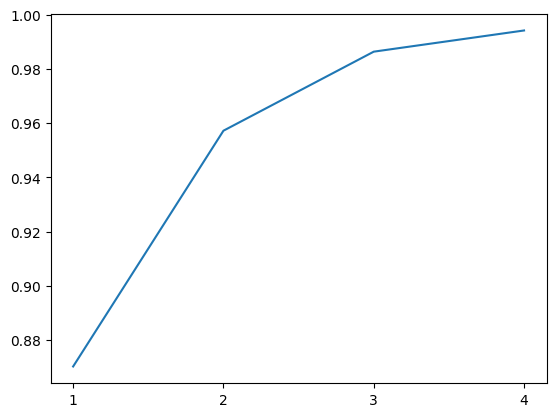

[0.87031097 0.95723427 0.98637392 0.99418576]


In [45]:
# cumulative explained variance
prefix_sum = np.copy(explained_variance_r)
for i in range(1, len(prefix_sum)):
    prefix_sum[i] += prefix_sum[i-1]
plt.plot(np.arange(1, len(explained_variance_r)+1, step=1), prefix_sum)
plt.xticks(np.arange(1, len(explained_variance_r)+1, step=1))
# plt.yscale('log')
plt.show()
print(prefix_sum)

The first 2 modes already explain 95.7% of the variance, and the first 3 explain 98.6%.

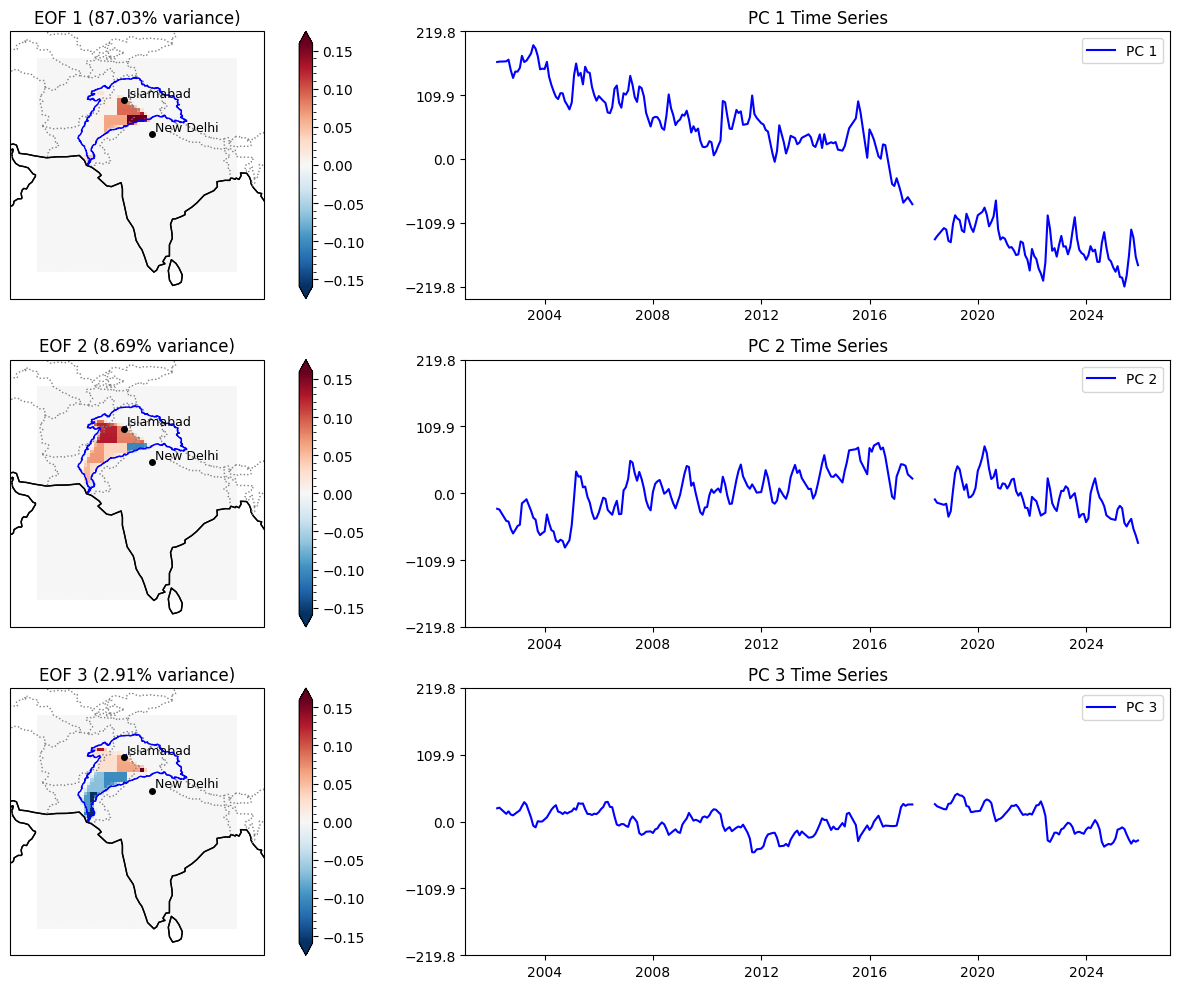

In [46]:
plot_n_r(3)

As can be seen above, the signal coming from the New Delhi area (first mode of the EOF analysis over India and Pakistan) is even more dominating, now explaining 87% of the variance and probably including the anthropogenic activities that we want to see in the lower Indus Basin. Since the two other significant modes do not show a clear yearly pattern, we will use the results of the EOF analysis over India and Pakistan for the rest of our analysis.

# 7. External dataset: Data Extraction and Time Series Construction

### 7.1. Approximation of climate-driven ∆TWS

In [47]:
# Time series extraction: ET, P, RO for each year over cropland area
et_vals, p_vals, ro_vals = [], [], []

for year in years:

    # Evapotranspiration (MODIS MOD16A2GF): annual sum, scaled by 0.1, masked to cropland
    et_img = (ee.ImageCollection('MODIS/061/MOD16A2GF')
                .filterDate(f'{year}-01-01', f'{year}-12-31')
                .select('ET').sum().multiply(0.1).updateMask(cropland_mask))
    et_val = et_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=indus_geom,
        scale=1000, maxPixels=1e13
    ).getInfo().get('ET', 0)

    # Precipitation (CHIRPS daily): annual sum, masked to cropland and reprojected to ET grid
    p_img = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
               .filterDate(f'{year}-01-01', f'{year}-12-31')
               .select('precipitation').sum().updateMask(cropland_mask)
               .resample('bilinear').reproject(crs=et_img.projection()))
    p_val = p_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=indus_geom,
        scale=1000, maxPixels=1e13
    ).getInfo().get('precipitation', 0)

    # Runoff (ERA5-Land monthly): surface + subsurface runoff, converted from m to mm (*1000)
    ro_img = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                .filterDate(f'{year}-01-01', f'{year}-12-31')
                .select(['surface_runoff_sum', 'sub_surface_runoff_sum'])
                .map(lambda img: img.select('surface_runoff_sum')
                                    .add(img.select('sub_surface_runoff_sum')))
                .sum().multiply(1000).clip(indus_geom))
    ro_val = ro_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=indus_geom,
        scale=1000, maxPixels=1e13
    ).getInfo().get('surface_runoff_sum', 0)

    et_vals.append(et_val)
    p_vals.append(p_val)
    ro_vals.append(ro_val)

# Compute climate-driven ΔTWS = P - ET - RO
# (This represents the expected TWS change from climate alone, without human influence)
delta_tws_no_irr = [p - et - ro for p, et, ro in zip(p_vals, et_vals, ro_vals)]

### 7.2. Approximation of anthropogenic-driven ∆TWS

In [48]:
# Load crop water use (CWU) data from ACEA NetCDF files
# (One file per crop, downloaded from GitHub and opened in-memory with xarray)
BASE_URL = "https://raw.githubusercontent.com/aferrini-art/indus-project-crop-data/main/Crop%20type%20cwu/"
crop_files = {
    'wheat':     'cwu_wheat_average_2010_2019.nc',
    'rice':      'cwu_rice_average_2010_2019.nc',
    'maize':     'cwu_maize_average_2010_2019.nc',
    'sorghum':   'cwu_sorghum_average_2010_2019.nc',
    'millet':    'cwu_millet_average_2010_2019.nc',
    'sugarcane': 'cwu_sugar_cane_average_2010_2019.nc',
}

datasets = {}
for crop, filename in crop_files.items():
    url      = BASE_URL + filename
    response = requests.get(url)
    ds       = xr.open_dataset(io.BytesIO(response.content))
    var_name = list(ds.data_vars)[0]
    datasets[crop] = ds[var_name]

print("Croptype Dataset loaded:", list(datasets.keys()))


# Crop area fractions over the Lower Indus Basin (Gallup Pakistan, 2025)
crop_fraction = {
    "wheat":     0.549,
    "rice":      0.199,
    "maize":     0.050,
    "sorghum":   0.050,
    "millet":    0.050,
    "sugarcane": 0.102,
}

crop_colors = {
    'wheat':     '#f1c40f',
    'rice':      '#2ecc71',
    'maize':     '#3498db',
    'sorghum':   '#9b59b6',
    'millet':    '#e67e22',
    'sugarcane': '#1abc9c',
}


# Compute irrigated CWU: spatial mean over the Indus Basin per crop
# (Sugarcane uses a wider bounding box (full Pakistan) due to sparse valid pixels in the narrower region;
#  the broader clip still yields a representative mean (~551 mm))

cwu_irrigated = {}
print("\nIrrigated CWU from ACEA dataset (Indus Basin spatial mean):")

for crop, filename in crop_files.items():
    url      = BASE_URL + filename
    response = requests.get(url)
    ds       = xr.open_dataset(io.BytesIO(response.content))

    if crop == 'sugarcane':
        ds_clip = ds.sel(lat=slice(38.0, 20.0), lon=slice(60.0, 85.0))
    else:
        ds_clip = ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

    mean_cwu = float(ds_clip['cwu_irrigated'].mean(skipna=True))
    cwu_irrigated[crop] = mean_cwu
    print(f"  {crop}: {mean_cwu:.1f} mm  ({crop_fraction[crop]*100:.1f}% of cropland area)")


# Time series: cropland extent and total irrigation demand per year
total_area_km2  = []
water_by_crop   = {c: [] for c in crop_fraction}
water_total_km3 = []

for year in years:

    # Cropland extent from MODIS Land Cover (classes 12 + 14), clipped to basin
    modis    = (ee.ImageCollection('MODIS/061/MCD12Q1')
                  .filterDate(f'{year}-01-01', f'{year}-12-31')
                  .first().select('LC_Type1').clip(indus_geom))
    cropland = modis.eq(12).Or(modis.eq(14))
    area_km2 = (cropland
        .multiply(ee.Image.pixelArea()).divide(1e6)
        .reduceRegion(reducer=ee.Reducer.sum(),
                      geometry=indus_geom, scale=500, maxPixels=1e13)
        .getInfo().get('LC_Type1', 0))

    # Irrigation volume per crop (km³) = area × crop fraction × CWU [mm → km³]
    w_total = 0
    for crop, frac in crop_fraction.items():
        w = area_km2 * frac * cwu_irrigated[crop] * 1e-6
        water_by_crop[crop].append(w)
        w_total += w

    total_area_km2.append(area_km2)
    water_total_km3.append(w_total)


# Compute anthropogenic ΔTWS = P - ET - RO - Irrigation
# (Irrigation is converted from km³ to mm over the basin area for consistency)

area_basin_km2 = indus_geom.area().divide(1e6).getInfo()
irr_mm         = [w * 1e9 / (area_basin_km2 * 1e6) * 1000 for w in water_total_km3]
delta_tws_full = [p - et - ro - irr for p, et, ro, irr in zip(p_vals, et_vals, ro_vals, irr_mm)]

Croptype Dataset loaded: ['wheat', 'rice', 'maize', 'sorghum', 'millet', 'sugarcane']

Irrigated CWU from ACEA dataset (Indus Basin spatial mean):
  wheat: 347.6 mm  (54.9% of cropland area)
  rice: 561.1 mm  (19.9% of cropland area)
  maize: 326.2 mm  (5.0% of cropland area)
  sorghum: 470.5 mm  (5.0% of cropland area)
  millet: 368.4 mm  (5.0% of cropland area)
  sugarcane: 1349.0 mm  (10.2% of cropland area)


# 8. External Dataset: Results and Data Visualization

### 8.1. Temporal Evolution of Precipitation, Evapotranspiration and Runoff

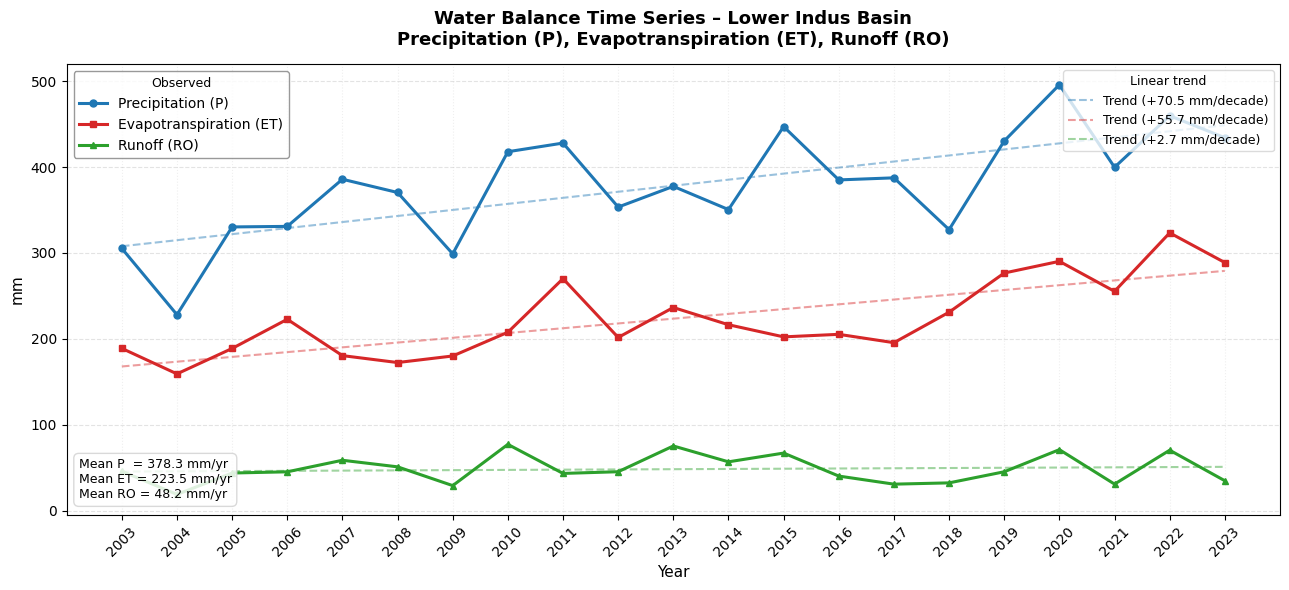

In [50]:
# Plot water balance time series: Precipitation, ET, and Runoff
fig, ax = plt.subplots(figsize=(13, 6))

# Line colors
col_p  = '#1f77b4'   # blue  – Precipitation
col_et = '#d62728'   # red   – Evapotranspiration
col_ro = '#2ca02c'   # green – Runoff

# Main observed time series
ax.plot(years, p_vals,  color=col_p,  lw=2.2, marker='o', ms=5, label='Precipitation (P)')
ax.plot(years, et_vals, color=col_et, lw=2.2, marker='s', ms=5, label='Evapotranspiration (ET)')
ax.plot(years, ro_vals, color=col_ro, lw=2.2, marker='^', ms=5, label='Runoff (RO)')

# Dashed linear trend lines (faded) with slope in mm/decade
for vals, col in zip([p_vals, et_vals, ro_vals], [col_p, col_et, col_ro]):
    z   = np.polyfit(years, vals, 1)
    fit = np.poly1d(z)(years)
    ax.plot(years, fit,
            color=col, lw=1.5, linestyle='--', alpha=0.45,
            label=f'Trend ({z[0]*10:+.1f} mm/decade)')

# Axes, ticks and grid
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('mm', fontsize=11)
ax.set_title('Water Balance Time Series – Lower Indus Basin\n'
             'Precipitation (P), Evapotranspiration (ET), Runoff (RO)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.35, axis='y')
ax.grid(True, linestyle=':', alpha=0.2,  axis='x')

# Two separate legends: observed series and trend lines
handles, labels = ax.get_legend_handles_labels()
obs_h   = handles[:3]; obs_l   = labels[:3]
trend_h = handles[3:]; trend_l = labels[3:]

leg1 = ax.legend(obs_h, obs_l,
                 loc='upper left', fontsize=10,
                 frameon=True, facecolor='white', edgecolor='gray',
                 title='Observed', title_fontsize=9)
ax.add_artist(leg1)
ax.legend(trend_h, trend_l,
          loc='upper right', fontsize=9,
          frameon=True, facecolor='white', edgecolor='lightgray',
          title='Linear trend', title_fontsize=9)

# Summary statistics box (bottom-left corner)
stats_text = (
    f"Mean P  = {np.mean(p_vals):.1f} mm/yr\n"
    f"Mean ET = {np.mean(et_vals):.1f} mm/yr\n"
    f"Mean RO = {np.mean(ro_vals):.1f} mm/yr"
)
ax.text(0.01, 0.03, stats_text,
        transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgray', alpha=0.85))

plt.tight_layout()
plt.savefig('water_balance_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2. Temporal Evolution of Cropland Extent and Irrigation Water Demand by Crop

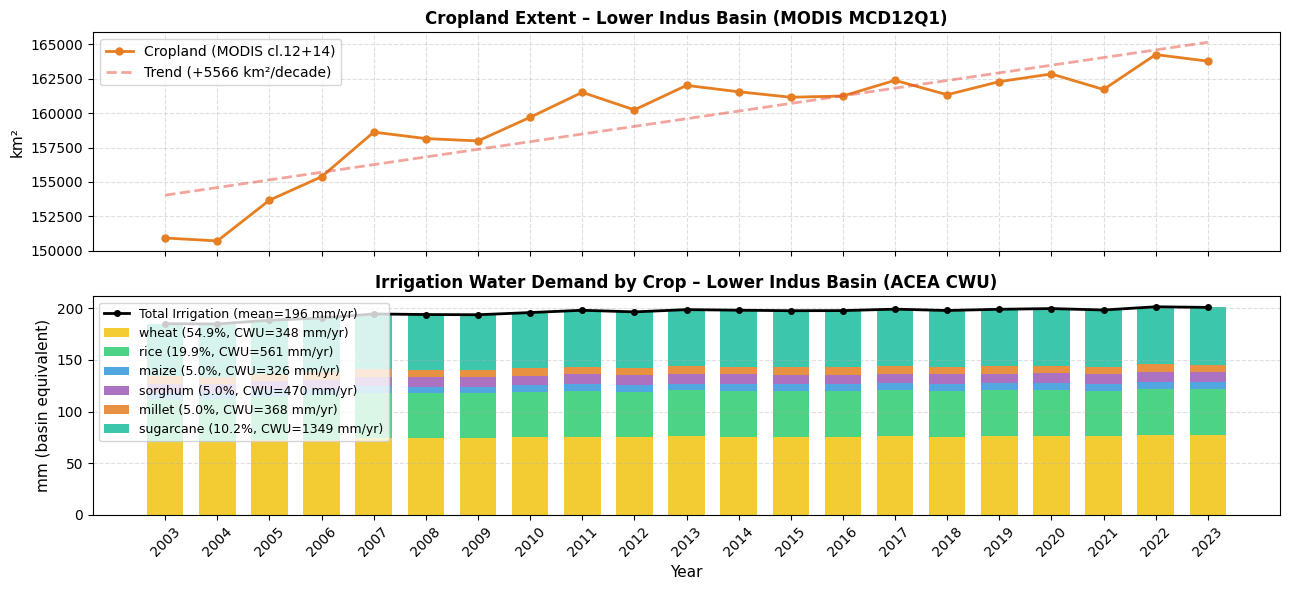


Mean total irrigation: 195.8 mm/yr
Min: 184.9 | Max: 201.5 mm/yr


In [51]:
# Plot cropland extent and irrigation demand: two-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Panel 1: cropland area over time with linear trend
ax1.plot(years, total_area_km2, color='#e67e22', lw=2, marker='o', ms=5,
         label='Cropland (MODIS cl.12+14)')
c_area = np.polyfit(years, total_area_km2, 1)
ax1.plot(years, np.poly1d(c_area)(years), color='#e74c3c', lw=2,
         linestyle='--', alpha=0.5,
         label=f'Trend ({c_area[0]*10:+.0f} km²/decade)')
ax1.set_title('Cropland Extent – Lower Indus Basin (MODIS MCD12Q1)', fontweight='bold')
ax1.set_ylabel('km²', fontsize=11)
ax1.legend(frameon=True, fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# Panel 2: stacked bar chart of irrigation demand by crop (mm basin-equivalent)
bottom = np.zeros(len(years))
for crop, vals in water_by_crop.items():
    vals_mm = [v * 1e9 / (area_basin_km2 * 1e6) * 1000 for v in vals]
    ax2.bar(years, vals_mm, bottom=bottom, color=crop_colors[crop],
            alpha=0.85, width=0.7,
            label=f'{crop} ({crop_fraction[crop]*100:.1f}%, CWU={cwu_irrigated[crop]:.0f} mm/yr)')
    bottom += np.array(vals_mm)

# Total irrigation line overlaid on the stacked bars
irr_mm_plot = [w * 1e9 / (area_basin_km2 * 1e6) * 1000 for w in water_total_km3]
ax2.plot(years, irr_mm_plot, color='black', lw=2, marker='o', ms=4,
         label=f'Total Irrigation (mean={np.mean(irr_mm_plot):.0f} mm/yr)')
ax2.set_title('Irrigation Water Demand by Crop – Lower Indus Basin (ACEA CWU)', fontweight='bold')
ax2.set_ylabel('mm (basin equivalent)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_xticks(years)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(frameon=True, fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('cropland_irrigation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean total irrigation: {np.mean(irr_mm_plot):.1f} mm/yr")
print(f"Min: {min(irr_mm_plot):.1f} | Max: {max(irr_mm_plot):.1f} mm/yr")

### 8.3. Time Series Analysis of climate and anthropogenic ∆TWS Components

8.3.1. Annual ∆TWS: Climate-driven vs Anthropogenic contribution

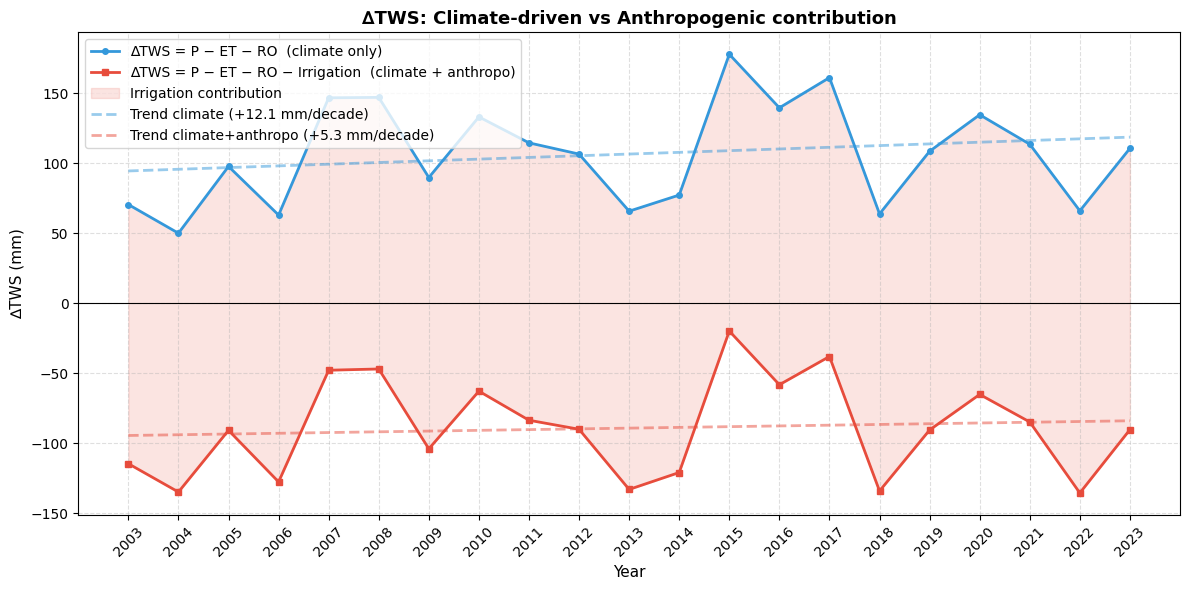

Mean ∆TWS climate only:       +106.7 mm/yr
Mean ∆TWS climate+anthropo:   -89.1 mm/yr
Mean irrigation contribution: +195.8 mm/yr


In [56]:
# Plot ΔTWS: climate-driven vs anthropogenic contribution
fig, ax = plt.subplots(figsize=(12, 6))

# Two ΔTWS curves: climate only (P−ET−RO) and full budget (P−ET−RO−Irrigation)
ax.plot(years, delta_tws_no_irr, color='#3498db', lw=2, marker='o', ms=4,
        label='∆TWS = P − ET − RO  (climate only)')
ax.plot(years, delta_tws_full,   color='#e74c3c', lw=2, marker='s', ms=4,
        label='∆TWS = P − ET − RO − Irrigation  (climate + anthropo)')

# Shaded area between the two curves highlights the irrigation contribution
ax.fill_between(years, delta_tws_no_irr, delta_tws_full,
                alpha=0.15, color='#e74c3c', label='Irrigation contribution')

# Linear trend lines for both scenarios
c_no_irr = np.polyfit(years, delta_tws_no_irr, 1)
c_full   = np.polyfit(years, delta_tws_full,   1)
ax.plot(years, np.poly1d(c_no_irr)(years), color='#3498db', lw=2,
        linestyle='--', alpha=0.5,
        label=f'Trend climate ({c_no_irr[0]*10:+.1f} mm/decade)')
ax.plot(years, np.poly1d(c_full)(years),   color='#e74c3c', lw=2,
        linestyle='--', alpha=0.5,
        label=f'Trend climate+anthropo ({c_full[0]*10:+.1f} mm/decade)')

# Zero reference line
ax.axhline(0, color='black', lw=0.8, linestyle='-')

# Axes, legend and grid
ax.set_title('∆TWS: Climate-driven vs Anthropogenic contribution',
             fontsize=13, fontweight='bold')
ax.set_ylabel('∆TWS (mm)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=True, fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('delta_tws_climate_vs_anthropo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean ∆TWS climate only:       {np.mean(delta_tws_no_irr):+.1f} mm/yr")
print(f"Mean ∆TWS climate+anthropo:   {np.mean(delta_tws_full):+.1f} mm/yr")
print(f"Mean irrigation contribution: {np.mean(irr_mm):+.1f} mm/yr")

8.3.2. Cumulative ∆TWS Anomaly: Climate vs Anthropogenic signal

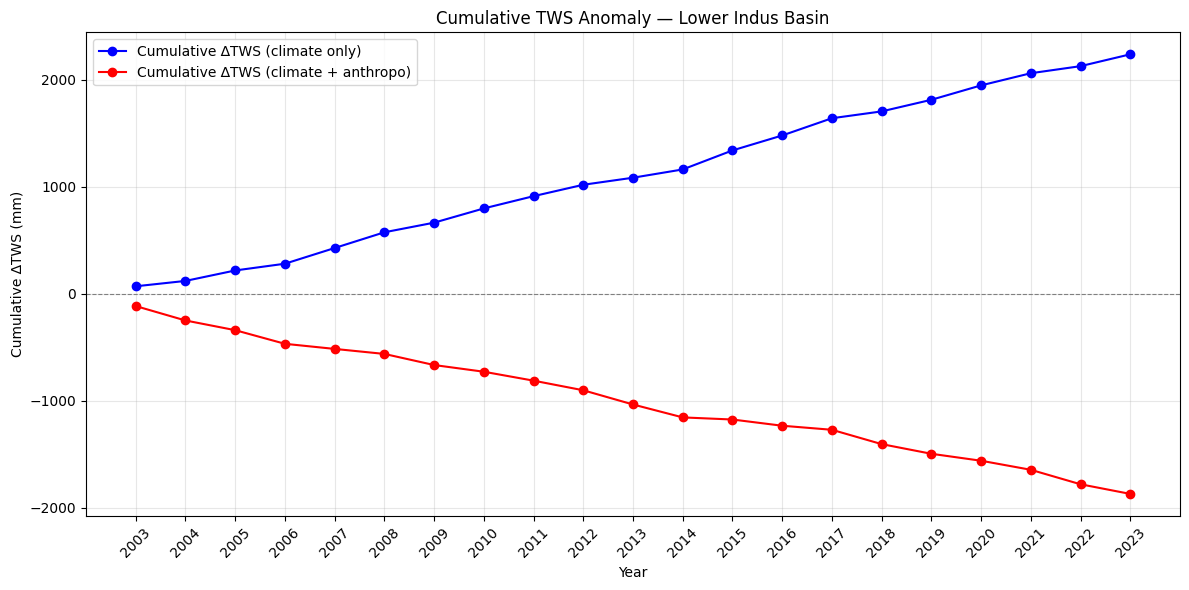

In [55]:
# Plot cumulative ΔTWS anomaly: climate-only vs climate + anthropogenic
tws_climate_cumsum  = np.cumsum(delta_tws_no_irr)
tws_anthropo_cumsum = np.cumsum(delta_tws_full)

plt.figure(figsize=(12, 6))
plt.plot(years, tws_climate_cumsum,  'b-o', label='Cumulative ∆TWS (climate only)')
plt.plot(years, tws_anthropo_cumsum, 'r-o', label='Cumulative ∆TWS (climate + anthropo)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Cumulative TWS Anomaly — Lower Indus Basin')
plt.xlabel('Year')
plt.ylabel('Cumulative ∆TWS (mm)')
plt.xticks(years, [str(y) for y in years], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()